Roadmap of EDA
1. Dataset Overview
2. Data Cleaning
3. Target Variable Analysis
4. Univariate Analysis
5. Bivariate Analysis
6. Correlation Analysis
7. Outlier Detection
8. Feature Engineering

1.Dataset overviews

In [2]:
#import laberies
import pandas as pd# to work with dataframes
import matplotlib.pyplot as plt# to plot graphs
import seaborn as sns# to plot graphs
import numpy as np# to work with arrays
import warnings # to ignore warnings
warnings.filterwarnings('ignore')



In [13]:
#load the dataset
df=pd.read_csv('winequality-white.csv', sep=';')# to load the white wine quality dataset from a CSV file into a pandas DataFrame called 'df' 

In [14]:
#know the dataset and its structure with information
df.head()# to display the first few rows of the DataFrame to get an initial look at the data
df.info()# to get a concise summary of the DataFrame, including the number of non-null entries and data types of each column    
df.shape# to get the dimensions of the DataFrame (number of rows and columns)
df.describe()# to get a statistical summary of the numerical columns in the DataFrame, including count, mean, standard deviation, min, max, and quartiles
df.tail()# to display the last few rows of the DataFrame to see the end of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7
4897,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6


2.Data cleaning


In [15]:
df.columns# to get the list of column names in the DataFrame
df.isnull().sum()# to check for missing values in each column of the DataFrame and sum them up to see how many missing values there are in each column  

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

there is not a null value so we need to move another step which is call as 

3.Target Variable Analysis


In [17]:
df['quality'].unique()# to get the unique values in the 'quality' column to see the different quality ratings present in the dataset
df['quality'].value_counts()# to count the occurrences of each unique value in the 'quality' column to see the distribution of quality ratings in the dataset

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

4.Univariate Analysis
how the value is distributred 

examaple :ph alochol

In [18]:
df['alcohol'].describe()# to get a statistical summary of the 'alcohol' column to understand the distribution of alcohol content in the white wine dataset  

count    4898.000000
mean       10.514267
std         1.230621
min         8.000000
25%         9.500000
50%        10.400000
75%        11.400000
max        14.200000
Name: alcohol, dtype: float64

visualize alochol distrubution using histograph

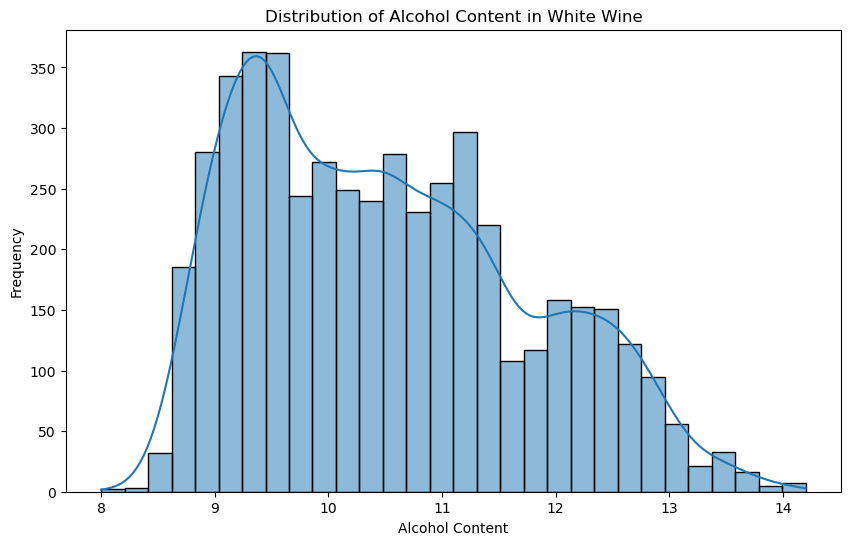

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df['alcohol'], kde=True, bins=30)# to plot a histogram of the 'alcohol' column with a kernel density estimate (KDE) overlay and 30 bins to visualize the distribution of alcohol content in the white wine dataset
plt.title('Distribution of Alcohol Content in White Wine')# to set the title of the plot
plt.xlabel('Alcohol Content')# to set the x-axis label
plt.ylabel('Frequency')# to set the y-axis label
plt.show()# to display the plot

5.Bivariate Analysis

alochol vs quality

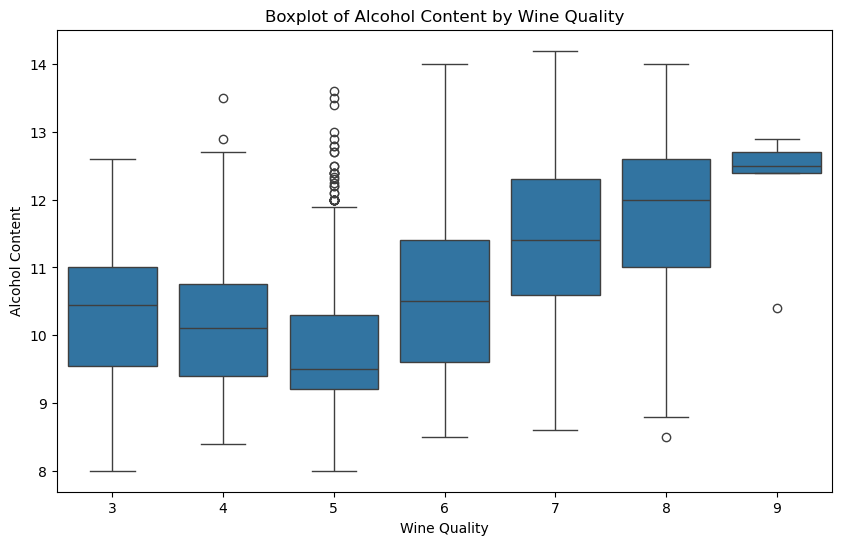

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Boxplot of Alcohol Content by Wine Quality')# to set the title of the plot
plt.xlabel('Wine Quality')# to set the x-axis label
plt.ylabel('Alcohol Content')# to set the y-axis label
plt.show()

6. Correlation Analysis

how the feature are related to each other and how they related the target variable 


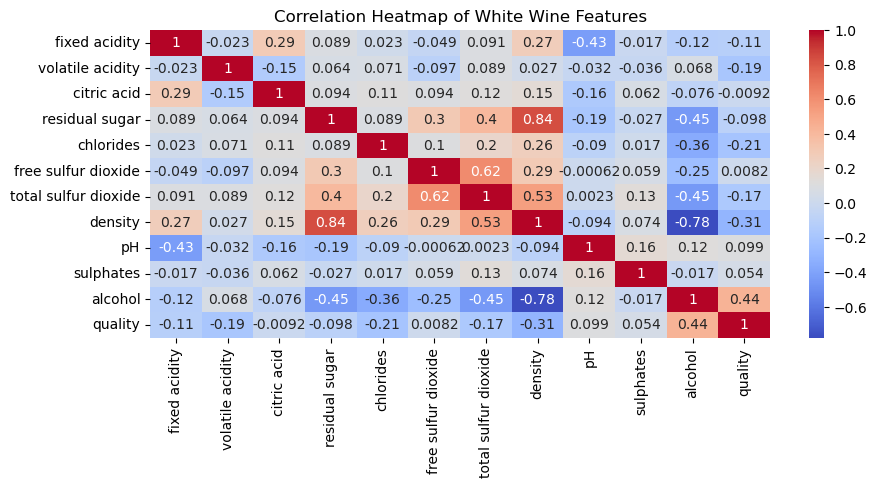

In [25]:
plt.figure(figsize=(10,4))
corr=df.corr()# to calculate the correlation matrix of the DataFrame to understand the relationships between different numerical features in the white wine dataset
sns.heatmap(corr, annot=True, cmap='coolwarm')# to plot a heatmap of the correlation matrix with annotations and a color map to visualize the strength and direction of correlations between features in the white wine dataset
plt.title('Correlation Heatmap of White Wine Features')# to set the title of the plot   
plt.show()# to display the plot


7. Outlier Detection

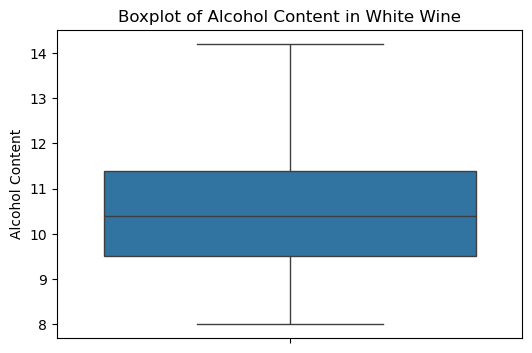

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['alcohol']) # to plot a boxplot of the 'alcohol' column to see the distribution of alcohol content and identify any outliers
plt.title('Boxplot of Alcohol Content in White Wine')
plt.ylabel('Alcohol Content')
plt.show()

In [28]:
#feature engineering
df['quality_label'] = df['quality'].apply(lambda x: 'Low' if x <= 4 else ('Medium' if x <= 6 else 'High')) # to create a new column 'quality_label' based on the 'quality' column, where wines with quality 4 or less are labeled as 'Low', those with quality 5 or 6 are labeled as 'Medium', and those with quality 7 or higher are labeled as 'High'
df.head()# to display the first few rows of the DataFrame to see the new '


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,Medium
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,Medium
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,Medium
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Medium
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Medium
